Requirements: install easyocr

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


([[np.int32(1600), np.int32(567)], [np.int32(2218), np.int32(567)], [np.int32(2218), np.int32(759)], [np.int32(1600), np.int32(759)]], 'REPLY', np.float64(0.9999360786528743))
([[np.int32(1597), np.int32(753)], [np.int32(2025), np.int32(753)], [np.int32(2025), np.int32(843)], [np.int32(1597), np.int32(843)]], 'CONNECT', np.float64(0.7075658032474148))


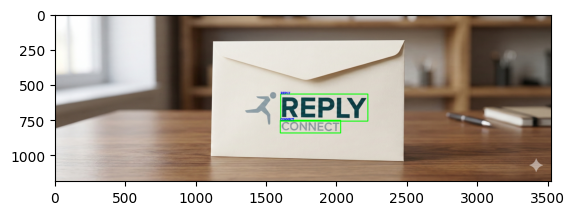

In [ ]:
import cv2
import easyocr
import matplotlib.pyplot as plt
import numpy as np

# read image
image_path = 'logo_recognition/busta_connect.png'

img = cv2.imread(image_path)

# instance text detector
reader = easyocr.Reader(['en'], gpu=True)

# detect text on image
text_ = reader.readtext(img)

threshold = 0.25
# draw bbox and text
for t_, t in enumerate(text_):
    print(t)

    bbox, text, score = t

    if score > threshold:
        cv2.rectangle(img, bbox[0], bbox[2], (0, 255, 0), 5)
        cv2.putText(img, text, bbox[0], cv2.FONT_HERSHEY_COMPLEX, 0.65, (255, 0, 0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()



--------------------
TESTO RILEVATO:
REPLY CONNECT
SCORE MEDIO: 0.9378
--------------------


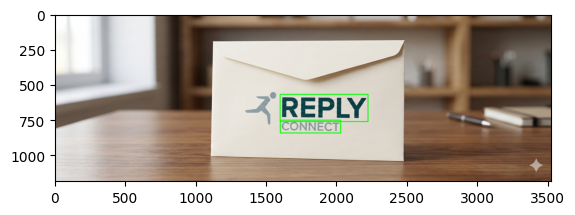

In [8]:
import cv2
import easyocr
import matplotlib.pyplot as plt
import numpy as np

# read image
image_path = 'logo_recognition/busta_connect.png'

img = cv2.imread(image_path)
# Aggiungi questo prima di reader.readtext(img)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Opzionale: aumenta il contrasto (Thresholding)
_, gray = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

text_ = reader.readtext(gray) # Passa l'immagine grigia invece di quella a colori


threshold = 0.25
all_texts = []
all_scores = []

# Ordiniamo i risultati dall'alto verso il basso (coordinata Y)
text_.sort(key=lambda x: x[0][0][1])

for t in text_:
    bbox, text, score = t

    if score > threshold:
        all_texts.append(text)
        all_scores.append(score)
        
        # Disegno bbox sul frame (opzionale)
        cv2.rectangle(img, bbox[0], bbox[2], (0, 255, 0), 5)

# Output finale aggregato
if all_texts:
    full_text = " ".join(all_texts)
    average_score = sum(all_scores) / len(all_scores)
    
    print("-" * 20)
    print(f"TESTO RILEVATO:\n{full_text}")
    print(f"SCORE MEDIO: {average_score:.4f}")
    print("-" * 20)
else:
    print("Nessun testo rilevato sopra la soglia.")
# --- FINO A QUI ---

# Mostra l'immagine con i rettangoli
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()